# Research Assistant Agent
**It’s a mini agentic AI system that demonstrates how to chain reasoning steps (research → critique → finalize) in a structured graph, instead of relying on a single LLM prompt.**

In [ ]:
!pip install langgraph langchain-openai groq graphviz pydot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 19.2 MB/s eta 0:00:00


In [ ]:
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from groq import Groq
from IPython.display import Image, display

In [ ]:
from google.colab import userdata
groq_api = userdata.get('GROQ_API_KEY')

In [ ]:
llm = ChatOpenAI(model_name="llama-3.3-70b-versatile",
                 temperature=0.0,
                 openai_api_base="https://api.groq.com/openai/v1",
                 openai_api_key=groq_api
                 )

In [ ]:
text = llm.invoke("Who is Imran Khan?")

In [ ]:
text

AIMessage(content="Imran Khan is a Pakistani politician, former cricketer, and philanthropist who served as the 22nd Prime Minister of Pakistan from August 2018 to April 2022. He is the founder and chairman of the Pakistan Tehreek-e-Insaf (PTI) party, which is one of the largest political parties in Pakistan.\n\nEarly Life and Cricket Career:\nImran Khan was born on October 5, 1952, in Lahore, Pakistan. He came from a wealthy family and was educated at the University of Oxford, where he studied Philosophy, Politics, and Economics. Khan is also a renowned cricketer, having played for the Pakistani national team from 1971 to 1992. He was a successful fast bowler and led the team to victory in the 1992 Cricket World Cup.\n\nPolitical Career:\nImran Khan entered politics in the 1990s and founded the PTI party in 1996. He initially struggled to gain traction, but his party's popularity grew over the years, especially among young people and the middle class. The PTI party's platform focuses 

In [ ]:
text.content

"Imran Khan is a Pakistani politician, former cricketer, and philanthropist who served as the 22nd Prime Minister of Pakistan from August 2018 to April 2022. He is the founder and chairman of the Pakistan Tehreek-e-Insaf (PTI) party, which is one of the largest political parties in Pakistan.\n\nEarly Life and Cricket Career:\nImran Khan was born on October 5, 1952, in Lahore, Pakistan. He came from a wealthy family and was educated at the University of Oxford, where he studied Philosophy, Politics, and Economics. Khan is also a renowned cricketer, having played for the Pakistani national team from 1971 to 1992. He was a successful fast bowler and led the team to victory in the 1992 Cricket World Cup.\n\nPolitical Career:\nImran Khan entered politics in the 1990s and founded the PTI party in 1996. He initially struggled to gain traction, but his party's popularity grew over the years, especially among young people and the middle class. The PTI party's platform focuses on anti-corruption

In [ ]:
# define the state

class State(dict):
  input: str
  research: str
  critique: str
  final: str

In [ ]:
# defining the node of the graph

def research_node(state:State):

  response = llm.invoke(f"Sumarize the Topic: {state['input']}")
  return {'research': response.content}


In [ ]:
def critic_node(state:State):

  response = llm.invoke(f"Here is the research summary: {state['research']}\n\n"
  f"Please critique it and point out missing details or weeknesses.")

  return {'critique': response.content}

In [ ]:
def finalizer_node(state:State):
  response = llm.invoke(
      f"Topic: {state['input']}\n\n"
      f"Research Summary: {state['research']}\n\n"
      f"Critique: {state['critique']}\n\n"
      f"Now Write a refined final answer."
  )

  return {'final': response.content}

In [ ]:
# building Graph

workflow = StateGraph(State)

#adding nodes
workflow.add_node("research", research_node)
workflow.add_node("critic", critic_node)
workflow.add_node("finalizer", finalizer_node)


workflow.set_entry_point('research')
# flow of the graph
workflow.add_edge('research', 'critic')
workflow.add_edge('critic', 'finalizer')
workflow.add_edge('finalizer', END)



print(workflow.nodes.keys())

dict_keys(['research', 'critic', 'finalizer'])


In [ ]:
# compiling the grpah

app = workflow.compile()

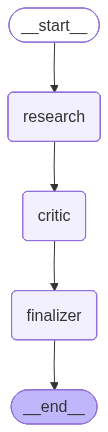

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
research_topic = "Impact of Artificial Intelligence on Healthcare"
result = app.invoke({"input": research_topic})

print("🔹 User Topic:", research_topic)


🔹 User Topic: Impact of Artificial Intelligence on Healthcare


In [ ]:
print("\n📘 Research Summary:\n", result["research"])


📘 Research Summary:
 **Impact of Artificial Intelligence on Healthcare:**

Artificial Intelligence (AI) is transforming the healthcare industry in various ways, improving patient outcomes, and streamlining clinical workflows. The impact of AI on healthcare can be summarized as follows:

**Positive Impacts:**

1. **Improved Diagnosis**: AI-powered algorithms can analyze medical images, lab results, and patient data to diagnose diseases more accurately and quickly.
2. **Personalized Medicine**: AI helps tailor treatment plans to individual patients based on their genetic profiles, medical histories, and lifestyle factors.
3. **Enhanced Patient Engagement**: AI-powered chatbots and virtual assistants improve patient communication, education, and engagement.
4. **Streamlined Clinical Workflows**: AI automates administrative tasks, reducing paperwork and allowing healthcare professionals to focus on patient care.
5. **Predictive Analytics**: AI analyzes large datasets to predict patient ou

In [ ]:
print("\n🧐 Critique:\n", result["critique"])


🧐 Critique:
 **Overall Assessment:**
The research summary provides a comprehensive overview of the impact of Artificial Intelligence (AI) on the healthcare industry, highlighting both positive and negative effects. However, there are some areas that require more attention, and some details are missing or could be improved upon.

**Strengths:**

1. **Clear structure**: The summary is well-organized, making it easy to follow and understand.
2. **Balance of positive and negative impacts**: The summary presents a balanced view of the effects of AI on healthcare, acknowledging both benefits and challenges.
3. **Future directions**: The summary provides a clear outline of potential future developments in the field.

**Weaknesses and Suggestions for Improvement:**

1. **Lack of specific examples**: The summary could benefit from concrete examples of AI applications in healthcare, such as IBM's Watson for Oncology or Google's DeepMind Health.
2. **Insufficient discussion of current challenges

In [ ]:
print("\n✅ Final Refined Answer:\n", result["final"])



✅ Final Refined Answer:
 **Refined Final Answer: The Impact of Artificial Intelligence on Healthcare**

The integration of Artificial Intelligence (AI) in the healthcare industry has transformative potential, with far-reaching implications for patient outcomes, clinical workflows, and the overall quality of care. This refined summary provides a comprehensive overview of the positive and negative impacts of AI on healthcare, as well as future directions and areas for improvement.

**Positive Impacts:**

1. **Improved Diagnosis**: AI-powered algorithms can analyze medical images, lab results, and patient data to diagnose diseases more accurately and quickly, as seen in IBM's Watson for Oncology, which has demonstrated high accuracy in detecting cancer.
2. **Personalized Medicine**: AI helps tailor treatment plans to individual patients based on their genetic profiles, medical histories, and lifestyle factors, leading to better patient outcomes and increased patient satisfaction.
3. **En